# Week 5: Function Approximation in Reinforcement Learning

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*From linear value functions to deep policies and quantum control*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(5)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- explain why tabular value functions fail in continuous and high-dimensional systems;
- construct linear value approximators from physically meaningful features;
- derive semi-gradient Monte Carlo, TD, and Q-learning updates;
- explain the roles of replay buffers and target networks in DQN;
- distinguish value approximation from direct policy approximation;
- implement a small policy-gradient controller for quantum state preparation;
- evaluate a learned policy against transparent physical baselines.

The notebook deliberately separates **representation**, **learning target**, and **control objective**. These are different design choices and should not be conflated.

## 1. From tables to trainable functions

In a tabular problem, each state or state-action pair has its own stored number,

$$
s\mapsto V(s),\qquad (s,a)\mapsto Q(s,a).
$$

Function approximation replaces the tables by parametrized functions,

$$
V(s)\approx \widehat v(s;\mathbf w),\qquad
Q(s,a)\approx \widehat q(s,a;\mathbf w).
$$

One update now changes many predictions because the same parameters are shared across states. This creates the central trade-off:

- **generalization:** information at one state improves nearby or structurally related states;
- **interference:** an update that improves one region may damage another.

If a state has $d$ components and each component is discretized into $m$ bins, a full table contains $m^d$ states. This exponential scaling is the curse of dimensionality. Continuous coordinates, many-particle configurations, wavefunctions, density matrices, and measurement histories therefore require a structured representation.

## 2. Linear function approximation

A linear value approximator is nonlinear in the state but linear in its parameters:

$$
\widehat v(s;\mathbf w)=\mathbf w^\top\boldsymbol\phi(s)
=\sum_{j=1}^{d}w_j\phi_j(s).
$$

The feature vector $\boldsymbol\phi(s)$ may contain polynomials, Fourier modes, radial basis functions, tile-coding indicators, symmetry-respecting descriptors, or learned embeddings. Its gradient is particularly simple,

$$
\nabla_{\mathbf w}\widehat v(s;\mathbf w)=\boldsymbol\phi(s).
$$

Linear approximation is useful pedagogically because every source of generalization is visible in the feature map.

### Example 1: different feature maps impose different notions of similarity

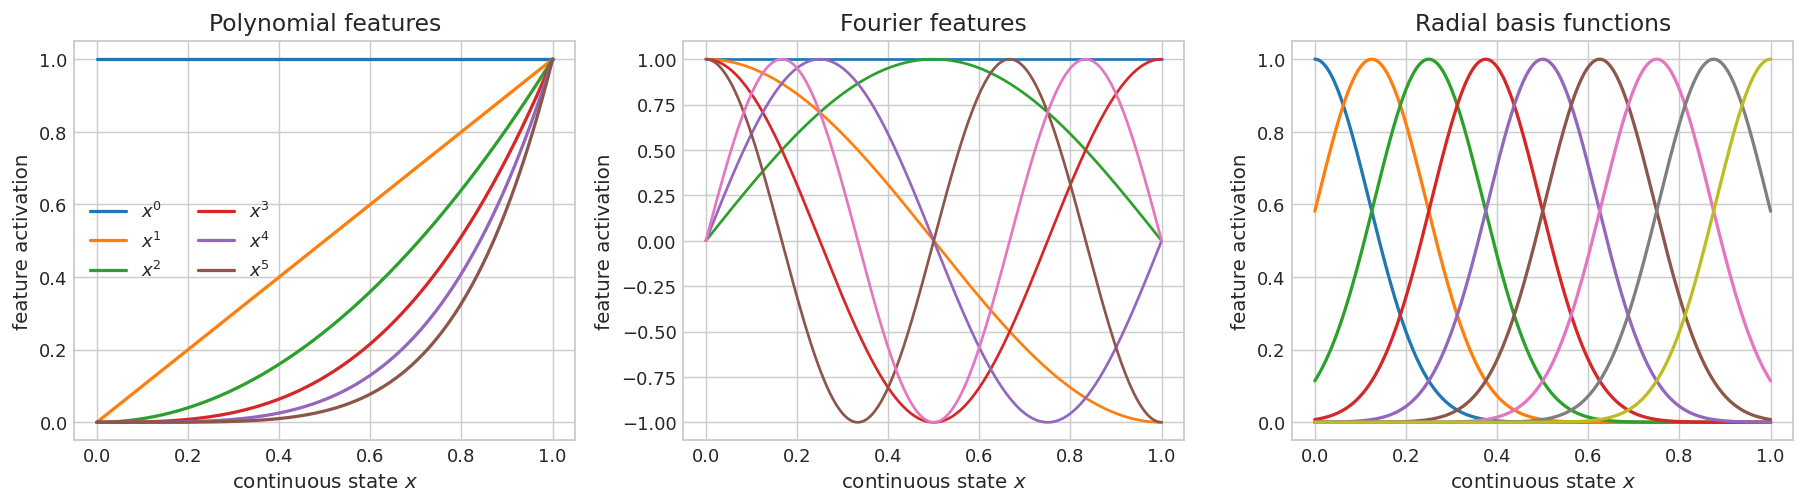

In [2]:
x = np.linspace(0, 1, 500)

def polynomial_features(x_values, degree=5):
    x_values = np.asarray(x_values)
    return np.stack([x_values**k for k in range(degree + 1)], axis=-1)

def fourier_features(x_values, order=4):
    x_values = np.asarray(x_values)
    features = [np.ones_like(x_values)]
    for k in range(1, order + 1):
        features.extend([np.cos(k * np.pi * x_values), np.sin(k * np.pi * x_values)])
    return np.stack(features, axis=-1)

rbf_centres = np.linspace(0, 1, 9)
rbf_width = 0.12

def rbf_features(x_values):
    x_values = np.asarray(x_values)[..., None]
    return np.exp(-0.5 * ((x_values - rbf_centres) / rbf_width) ** 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for j, column in enumerate(polynomial_features(x, degree=5).T):
    axes[0].plot(x, column, lw=1.8, label=fr"$x^{j}$")
axes[0].set_title("Polynomial features")
axes[0].legend(ncol=2)

for j, column in enumerate(fourier_features(x, order=3).T):
    axes[1].plot(x, column, lw=1.5)
axes[1].set_title("Fourier features")

for centre, column in zip(rbf_centres, rbf_features(x).T):
    axes[2].plot(x, column, lw=1.8, label=f"{centre:.2f}")
axes[2].set_title("Radial basis functions")

for ax in axes:
    ax.set_xlabel("continuous state $x$")
    ax.set_ylabel("feature activation")
plt.tight_layout()
plt.show()

Polynomial and Fourier features have global support: a parameter update can affect the entire domain. Radial basis functions are local, so interference is more limited. The best representation depends on known structure. Periodic variables suggest Fourier features; localized phenomena suggest tiles or radial bases; physical symmetries should be encoded whenever possible.

### One update changes a region, not one table entry

For a target $Y$ and squared loss

$$
L(\mathbf w)=\frac12\left[Y-\widehat v(s;\mathbf w)\right]^2,
$$

stochastic gradient descent gives

$$
\mathbf w\leftarrow\mathbf w+\alpha
\left[Y-\widehat v(s;\mathbf w)\right]\boldsymbol\phi(s).
$$

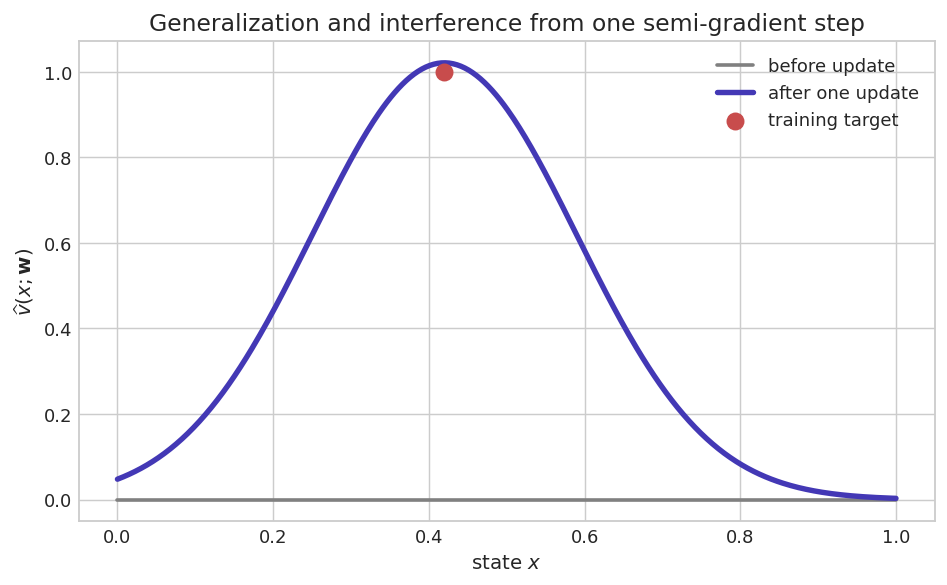

In [3]:
grid = np.linspace(0, 1, 400)
weights = np.zeros(len(rbf_centres))
update_state = 0.42
target = 1.0
learning_rate = 0.6

prediction_before = rbf_features(grid) @ weights
phi_update = rbf_features(np.array([update_state]))[0]
error = target - phi_update @ weights
weights = weights + learning_rate * error * phi_update
prediction_after = rbf_features(grid) @ weights

plt.plot(grid, prediction_before, color="0.5", lw=2, label="before update")
plt.plot(grid, prediction_after, color=UIO_PURPLE, lw=3, label="after one update")
plt.scatter([update_state], [target], s=80, color=UIO_RED, zorder=3,
            label="training target")
plt.xlabel("state $x$")
plt.ylabel(r"$\widehat v(x;\mathbf{w})$")
plt.title("Generalization and interference from one semi-gradient step")
plt.legend()
plt.show()

## 3. Choosing the learning target: Monte Carlo or TD

The optimizer is not the main conceptual difference between supervised learning and RL. The target is generated by interaction.

**Monte Carlo target**

$$
Y_t=G_t,\qquad
\mathbf w\leftarrow\mathbf w+\alpha
\left[G_t-\widehat v(S_t;\mathbf w)\right]
\nabla_{\mathbf w}\widehat v(S_t;\mathbf w).
$$

**One-step TD target**

$$
Y_t=R_{t+1}+\gamma\widehat v(S_{t+1};\mathbf w),
$$

$$
\delta_t=R_{t+1}+\gamma\widehat v(S_{t+1};\mathbf w)-\widehat v(S_t;\mathbf w),
$$

$$
\mathbf w\leftarrow\mathbf w+\alpha\delta_t
\nabla_{\mathbf w}\widehat v(S_t;\mathbf w).
$$

This is called a **semi-gradient** update because the bootstrapped target depends on $\mathbf w$, but standard TD does not differentiate through the target. Monte Carlo waits for a complete return and often has higher variance. TD updates immediately but introduces bias through bootstrapping.

### Example 2: semi-gradient MC and TD on a continuous representation

In [4]:
class RandomWalk21:
    # States 1,...,19 are nonterminal; 0 and 20 are terminal.
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)

    def reset(self):
        self.state = 10
        return self.state

    def step(self):
        self.state += -1 if self.rng.random() < 0.5 else 1
        terminal = self.state in (0, 20)
        reward = 1.0 if self.state == 20 else 0.0
        return self.state, reward, terminal

value_centres = np.linspace(0.05, 0.95, 7)
value_width = 0.16

def value_features(state):
    x_state = np.asarray(state, dtype=float)[..., None] / 20.0
    return np.exp(-0.5 * ((x_state - value_centres) / value_width) ** 2)

nonterminal_states = np.arange(1, 20)
true_values = nonterminal_states / 20.0

def approximate_values(weights):
    return value_features(nonterminal_states) @ weights

def train_prediction(method, episodes=500, alpha=0.025, seed=0):
    env = RandomWalk21(seed)
    weights = np.zeros(len(value_centres))
    rmse_history = []

    for _ in range(episodes):
        state = env.reset()
        states, rewards = [], []
        terminal = False
        while not terminal:
            states.append(state)
            next_state, reward, terminal = env.step()
            rewards.append(reward)

            if method == "TD(0)":
                next_value = 0.0 if terminal else value_features(next_state) @ weights
                prediction = value_features(state) @ weights
                delta = reward + next_value - prediction
                weights += alpha * delta * value_features(state)
            state = next_state

        if method == "Monte Carlo":
            terminal_return = rewards[-1]
            for visited_state in states:
                prediction = value_features(visited_state) @ weights
                weights += alpha * (terminal_return - prediction) * value_features(visited_state)

        rmse = np.sqrt(np.mean((approximate_values(weights) - true_values) ** 2))
        rmse_history.append(rmse)

    return weights, np.asarray(rmse_history)

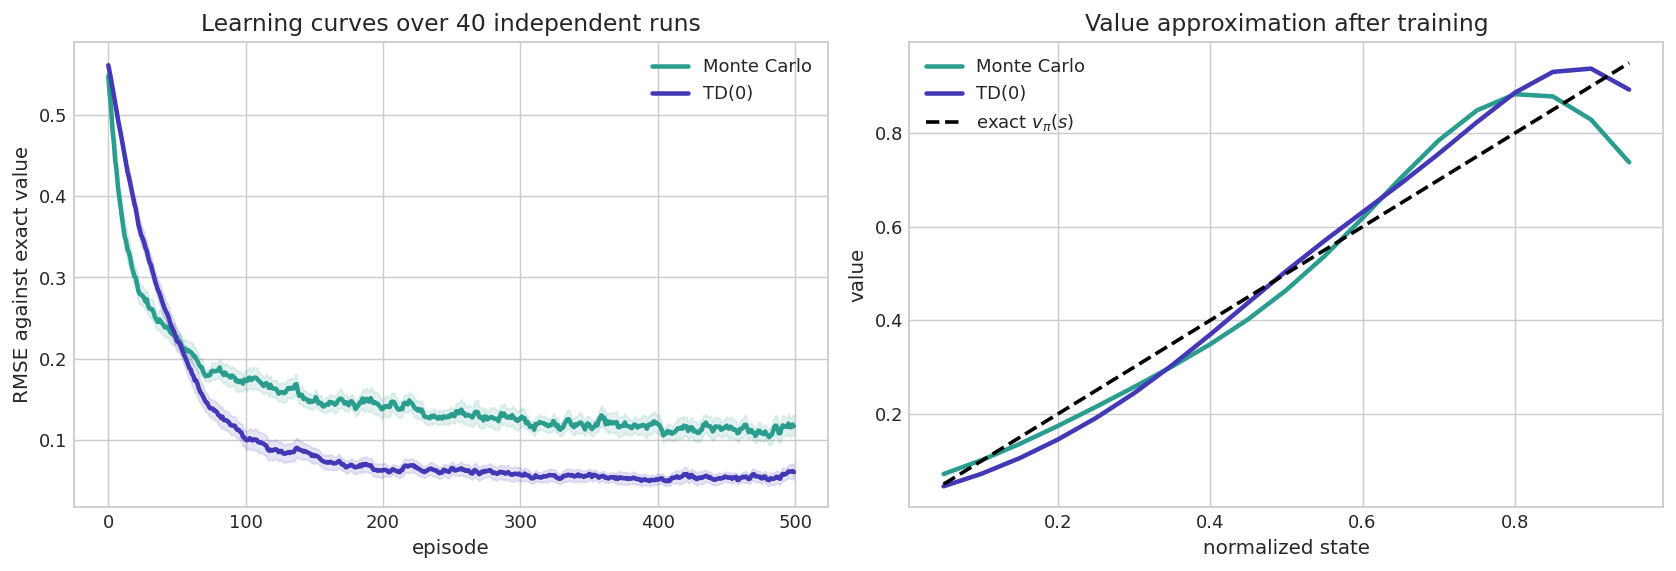

In [5]:
repetitions = 40
episodes = 500
histories = {"Monte Carlo": [], "TD(0)": []}
final_weights = {}

for method in histories:
    for seed in range(repetitions):
        # MC updates every visited state after an episode, so it requires a
        # smaller per-state step size for a fair and stable comparison.
        step_size = 0.0005 if method == "Monte Carlo" else 0.025
        weights, history = train_prediction(
            method, episodes=episodes, alpha=step_size, seed=seed
        )
        histories[method].append(history)
    final_weights[method] = weights
    histories[method] = np.stack(histories[method])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"Monte Carlo": UIO_GREEN, "TD(0)": UIO_PURPLE}
for method, samples in histories.items():
    mean = samples.mean(axis=0)
    sem = samples.std(axis=0) / np.sqrt(repetitions)
    axes[0].plot(mean, lw=2.5, color=colors[method], label=method)
    axes[0].fill_between(np.arange(episodes), mean - 1.96 * sem,
                         mean + 1.96 * sem, color=colors[method], alpha=0.13)
    axes[1].plot(nonterminal_states / 20, approximate_values(final_weights[method]),
                 lw=2.5, color=colors[method], label=method)

axes[0].set(xlabel="episode", ylabel="RMSE against exact value",
            title="Learning curves over 40 independent runs")
axes[0].legend()
axes[1].plot(nonterminal_states / 20, true_values, "k--", lw=2,
             label=r"exact $v_\pi(s)$")
axes[1].set(xlabel="normalized state", ylabel="value",
            title="Value approximation after training")
axes[1].legend()
plt.tight_layout()
plt.show()

The two methods estimate the same value function but use different stochastic targets. The precise ranking depends on step size and representation. Reporting a single learning curve without seeds, uncertainty bands, or hyperparameter sensitivity is not sufficient evidence.

## 4. Approximate action values and deep Q-learning

For control with discrete actions, a network often outputs one value per action,

$$
f_{\mathbf w}(s)=
\bigl(\widehat q(s,a_1;\mathbf w),\ldots,
\widehat q(s,a_m;\mathbf w)\bigr).
$$

Approximate Q-learning uses the target

$$
Y_t=R_{t+1}+\gamma\max_{a'}\widehat q(S_{t+1},a';\mathbf w^-),
$$

where $\mathbf w^-$ denotes target-network parameters. For a replay mini-batch $\mathcal B$,

$$
L(\mathbf w)=\frac{1}{2|\mathcal B|}
\sum_{(s,a,r,s')\in\mathcal B}
\left[Y(r,s')-\widehat q(s,a;\mathbf w)\right]^2.
$$

The replay buffer reduces temporal correlation and reuses data. The target network slows the movement of the labels. Neither device changes the Bellman objective; both address optimization inside a nonstationary feedback loop.

### Example 3: a small DQN built only with NumPy

In [6]:
class ContinuousLineWorld:
    # A continuous-state navigation task with two discrete actions.
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.max_steps = 70

    def reset(self):
        self.x = -0.85 + 0.03 * self.rng.normal()
        self.steps = 0
        return np.array([self.x])

    def step(self, action):
        displacement = -0.075 if action == 0 else 0.075
        old_x = self.x
        self.x = np.clip(self.x + displacement + 0.012 * self.rng.normal(), -1, 1)
        self.steps += 1
        reached_goal = self.x >= 0.88
        truncated = self.steps >= self.max_steps
        progress = self.x - old_x
        reward = -0.015 + 0.25 * progress + (1.0 if reached_goal else 0.0)
        return np.array([self.x]), reward, reached_goal or truncated, reached_goal


class TinyQNetwork:
    def __init__(self, seed=0, hidden=24):
        local_rng = np.random.default_rng(seed)
        self.W1 = local_rng.normal(scale=0.35, size=(1, hidden))
        self.b1 = np.zeros(hidden)
        self.W2 = local_rng.normal(scale=0.20, size=(hidden, 2))
        self.b2 = np.zeros(2)

    def predict(self, states):
        states = np.asarray(states).reshape(-1, 1)
        hidden = np.tanh(states @ self.W1 + self.b1)
        return hidden @ self.W2 + self.b2

    def train_batch(self, states, actions, targets, learning_rate=0.003):
        states = np.asarray(states).reshape(-1, 1)
        actions = np.asarray(actions, dtype=int)
        targets = np.asarray(targets)
        hidden = np.tanh(states @ self.W1 + self.b1)
        q_values = hidden @ self.W2 + self.b2
        errors = q_values[np.arange(len(states)), actions] - targets

        grad_q = np.zeros_like(q_values)
        grad_q[np.arange(len(states)), actions] = errors / len(states)
        grad_W2 = hidden.T @ grad_q
        grad_b2 = grad_q.sum(axis=0)
        grad_hidden = (grad_q @ self.W2.T) * (1 - hidden**2)
        grad_W1 = states.T @ grad_hidden
        grad_b1 = grad_hidden.sum(axis=0)

        self.W2 -= learning_rate * grad_W2
        self.b2 -= learning_rate * grad_b2
        self.W1 -= learning_rate * grad_W1
        self.b1 -= learning_rate * grad_b1
        return float(0.5 * np.mean(errors**2))

    def copy_from(self, other):
        for name in ["W1", "b1", "W2", "b2"]:
            setattr(self, name, getattr(other, name).copy())

In [7]:
def train_dqn(episodes=520, seed=10):
    local_rng = np.random.default_rng(seed)
    env = ContinuousLineWorld(seed)
    online = TinyQNetwork(seed)
    target = TinyQNetwork(seed + 1)
    target.copy_from(online)
    replay = []
    replay_capacity = 5000
    batch_size = 64
    gamma = 0.98
    update_count = 0
    returns, successes, losses = [], [], []

    for episode in range(episodes):
        state = env.reset()
        epsilon = max(0.04, 0.9 * np.exp(-episode / 130))
        total_return = 0.0
        done = False

        while not done:
            if local_rng.random() < epsilon:
                action = int(local_rng.integers(2))
            else:
                action = int(np.argmax(online.predict(state)[0]))

            next_state, reward, done, success = env.step(action)
            replay.append((state.copy(), action, reward, next_state.copy(), done))
            if len(replay) > replay_capacity:
                replay.pop(0)
            state = next_state
            total_return += reward

            if len(replay) >= batch_size:
                indices = local_rng.integers(0, len(replay), batch_size)
                batch = [replay[index] for index in indices]
                states = np.vstack([item[0] for item in batch])
                actions = np.array([item[1] for item in batch])
                rewards = np.array([item[2] for item in batch])
                next_states = np.vstack([item[3] for item in batch])
                dones = np.array([item[4] for item in batch], dtype=float)
                next_q = target.predict(next_states).max(axis=1)
                targets = rewards + gamma * (1 - dones) * next_q
                losses.append(online.train_batch(states, actions, targets))
                update_count += 1
                if update_count % 120 == 0:
                    target.copy_from(online)

        returns.append(total_return)
        successes.append(float(success))

    return online, np.asarray(returns), np.asarray(successes), np.asarray(losses)

q_network, dqn_returns, dqn_successes, dqn_losses = train_dqn()
print(f"Success rate over final 100 episodes: {dqn_successes[-100:].mean():.3f}")

Success rate over final 100 episodes: 1.000


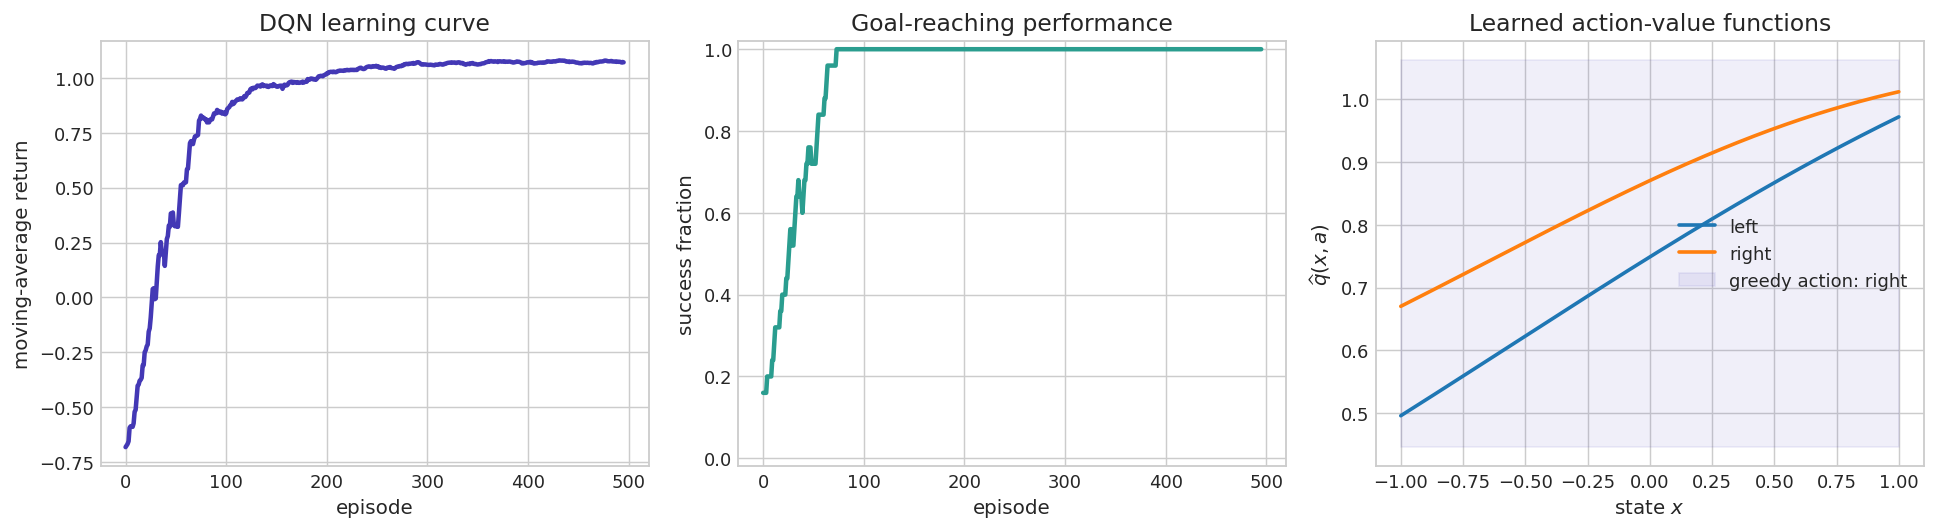

In [8]:
def moving_average(values, window):
    values = np.asarray(values)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

state_grid = np.linspace(-1, 1, 400)
q_grid = q_network.predict(state_grid)
greedy_actions = np.argmax(q_grid, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(moving_average(dqn_returns, 25), color=UIO_PURPLE, lw=2.5)
axes[0].set(xlabel="episode", ylabel="moving-average return",
            title="DQN learning curve")
axes[1].plot(moving_average(dqn_successes, 25), color=UIO_GREEN, lw=2.5)
axes[1].set(xlabel="episode", ylabel="success fraction",
            ylim=(-0.02, 1.02), title="Goal-reaching performance")
axes[2].plot(state_grid, q_grid[:, 0], lw=2, label="left")
axes[2].plot(state_grid, q_grid[:, 1], lw=2, label="right")
axes[2].fill_between(state_grid, q_grid.min() - 0.05, q_grid.max() + 0.05,
                     where=greedy_actions.astype(bool), color=UIO_PURPLE, alpha=0.08,
                     label="greedy action: right")
axes[2].set(xlabel="state $x$", ylabel=r"$\widehat q(x,a)$",
            title="Learned action-value functions")
axes[2].legend()
plt.tight_layout()
plt.show()

This environment is intentionally small enough to inspect. The state is continuous, so a lookup table is not used. The shared hidden layer generalizes values between nearby positions. A serious DQN study would additionally examine seed sensitivity, double-Q targets, reward scaling, gradient norms, replay composition, and out-of-distribution behavior.

### The deadly triad

Instability is particularly likely when three ingredients appear together:

1. function approximation,
2. bootstrapping,
3. off-policy learning.

DQN contains all three. Replay and target networks are useful engineering devices, but they are not a proof of convergence.

## 5. Direct policy approximation

Value-based methods learn values and derive a policy. Policy-gradient methods train a stochastic policy directly,

$$
\pi_\theta(a\mid s)=\Pr_\theta(A_t=a\mid S_t=s),
\qquad J(\theta)=\mathbb E_{\pi_\theta}[G_0].
$$

The log-derivative identity gives

$$
\nabla_\theta J(\theta)=
\mathbb E_{\pi_\theta}\left[
\sum_{t=0}^{T-1}\nabla_\theta\log\pi_\theta(A_t\mid S_t)G_t
\right].
$$

Subtracting a baseline $b(S_t)$ does not change the expected gradient but can reduce variance. With a learned critic,

$$
\widehat A_t=G_t-\widehat v(S_t;\mathbf w)
\quad\text{or}\quad
\widehat A_t\approx\delta_t,
$$

producing an actor-critic method.

## 6. PPO limits destructive policy updates

Define the probability ratio between a candidate policy and the policy that generated the data,

$$
r_t(\theta)=\frac{\pi_\theta(A_t\mid S_t)}
{\pi_{\theta_{\mathrm{old}}}(A_t\mid S_t)}.
$$

PPO uses the clipped surrogate objective

$$
L^{\mathrm{CLIP}}(\theta)=
\mathbb E_t\left[
\min\left(r_t(\theta)\widehat A_t,
\operatorname{clip}(r_t(\theta),1-\epsilon,1+\epsilon)\widehat A_t\right)
\right].
$$

Clipping removes the incentive for probability ratios to move far beyond the trusted interval when that movement would improve the sampled objective.

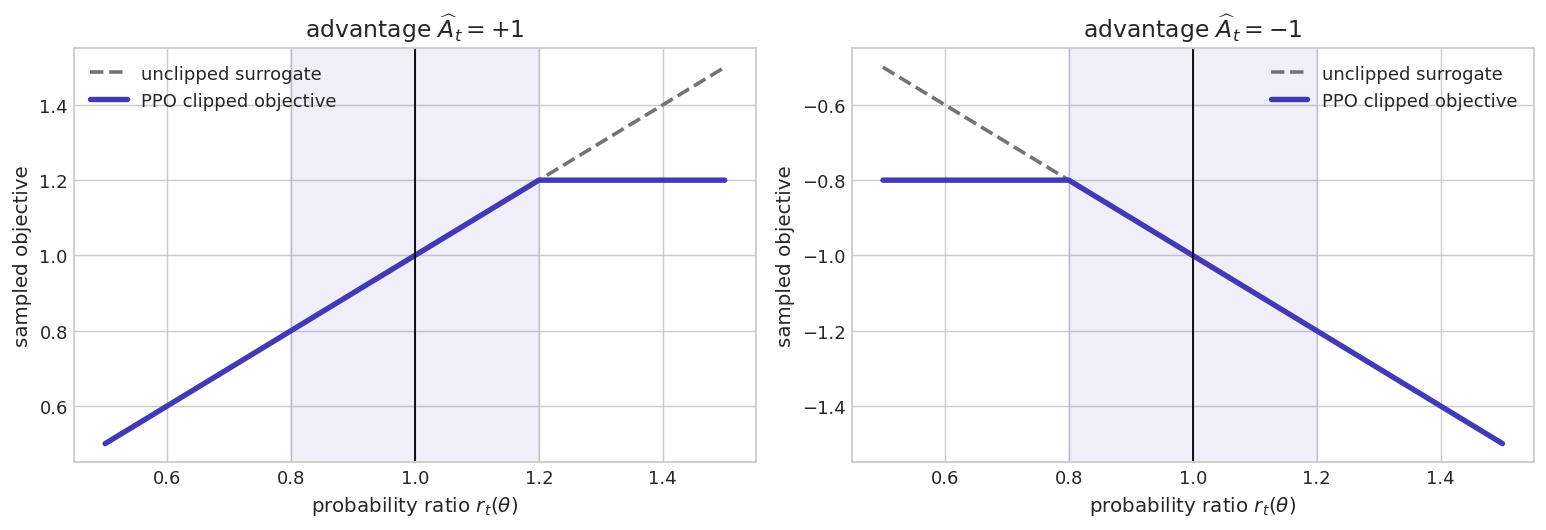

In [9]:
ratio = np.linspace(0.5, 1.5, 500)
epsilon_clip = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, advantage in zip(axes, [1.0, -1.0]):
    unclipped = ratio * advantage
    clipped_ratio = np.clip(ratio, 1 - epsilon_clip, 1 + epsilon_clip)
    clipped_objective = np.minimum(unclipped, clipped_ratio * advantage)
    ax.plot(ratio, unclipped, "--", color="0.45", lw=2,
            label="unclipped surrogate")
    ax.plot(ratio, clipped_objective, color=UIO_PURPLE, lw=3,
            label="PPO clipped objective")
    ax.axvspan(1 - epsilon_clip, 1 + epsilon_clip, color=UIO_PURPLE, alpha=0.08)
    ax.axvline(1, color="black", lw=1)
    ax.set(xlabel=r"probability ratio $r_t(\theta)$",
           ylabel="sampled objective",
           title=fr"advantage $\widehat A_t={advantage:+.0f}$")
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Application: quantum state preparation

Consider a controlled qubit with Hamiltonian

$$
H_t=\frac{\Delta}{2}\sigma_z+\frac{u_t}{2}\sigma_x,
$$

initial state $|\psi_0\rangle=|0\rangle$, and target $|\psi_*\rangle=|1\rangle$. The terminal fidelity is

$$
F_T=|\langle\psi_*|\psi_T\rangle|^2.
$$

A physically informed return can balance fidelity, control energy, and smoothness,

$$
G_0=F_T-\lambda\sum_{t=0}^{T-1}u_t^2
-\eta\sum_{t=1}^{T-1}(u_t-u_{t-1})^2.
$$

The following example trains a time-dependent softmax policy over a small set of bounded pulse amplitudes. It is an open-loop policy: its state is the time index. A feedback controller would condition the policy on measurement records or a belief state.

In [10]:
I2 = np.eye(2, dtype=complex)
SX = np.array([[0, 1], [1, 0]], dtype=complex)
SZ = np.array([[1, 0], [0, -1]], dtype=complex)
KET0 = np.array([1.0, 0.0], dtype=complex)
KET1 = np.array([0.0, 1.0], dtype=complex)

pulse_values = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
pulse_dt = 0.25
pulse_horizon = 12

def propagate_qubit(state, pulse, detuning, dt=pulse_dt):
    field_norm = np.sqrt(pulse**2 + detuning**2)
    if field_norm < 1e-12:
        return state.copy()
    generator = (pulse * SX + detuning * SZ) / field_norm
    unitary = np.cos(field_norm * dt / 2) * I2 - 1j * np.sin(field_norm * dt / 2) * generator
    return unitary @ state

def qubit_return(action_indices, detuning, energy_weight=0.0015,
                 smoothness_weight=0.001):
    pulses = pulse_values[np.asarray(action_indices)]
    fidelity = qubit_fidelity_from_pulses(pulses, detuning)
    energy_cost = energy_weight * np.sum(pulses**2)
    smoothness_cost = smoothness_weight * np.sum(np.diff(pulses)**2)
    return float(fidelity - energy_cost - smoothness_cost), float(fidelity)

def qubit_fidelity_from_pulses(pulses, detuning):
    state = KET0.copy()
    for pulse in pulses:
        state = propagate_qubit(state, pulse, detuning)
    fidelity = abs(np.vdot(KET1, state))**2
    return float(fidelity)

def softmax_rows(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

In [11]:
def train_qubit_policy(iterations=360, batch_size=100, seed=5):
    local_rng = np.random.default_rng(seed)
    logits = np.zeros((pulse_horizon, len(pulse_values)))
    # A weak physics-informed prior favors a positive resonant rotation,
    # while retaining substantial exploration over all bounded pulses.
    positive_unit_pulse = int(np.where(pulse_values == 1.0)[0][0])
    logits[:, positive_unit_pulse] = 0.8
    baseline = 0.0
    mean_fidelity_history = []
    mean_return_history = []

    for iteration in range(iterations):
        probabilities = softmax_rows(logits)
        gradients = np.zeros_like(logits)
        batch_returns, batch_fidelities = [], []
        trajectories = []

        for _ in range(batch_size):
            actions = np.array([
                local_rng.choice(len(pulse_values), p=probabilities[t])
                for t in range(pulse_horizon)
            ])
            detuning = local_rng.normal(0.0, 0.38)
            episode_return, fidelity = qubit_return(actions, detuning)
            trajectories.append((actions, episode_return))
            batch_returns.append(episode_return)
            batch_fidelities.append(fidelity)

        batch_returns = np.asarray(batch_returns)
        baseline = 0.90 * baseline + 0.10 * batch_returns.mean()
        for actions, episode_return in trajectories:
            advantage = episode_return - baseline
            for t, action in enumerate(actions):
                one_hot = np.zeros(len(pulse_values))
                one_hot[action] = 1.0
                gradients[t] += advantage * (one_hot - probabilities[t])

        learning_rate = 1.0 / np.sqrt(1 + iteration / 180)
        logits += learning_rate * gradients / batch_size
        mean_return_history.append(batch_returns.mean())
        mean_fidelity_history.append(np.mean(batch_fidelities))

    return logits, np.asarray(mean_return_history), np.asarray(mean_fidelity_history)

qubit_logits, qubit_returns, qubit_fidelities = train_qubit_policy()
learned_probabilities = softmax_rows(qubit_logits)
learned_actions = np.argmax(learned_probabilities, axis=1)
learned_pulses = pulse_values[learned_actions]
print("Greedy learned pulse sequence:", learned_pulses)

Greedy learned pulse sequence: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


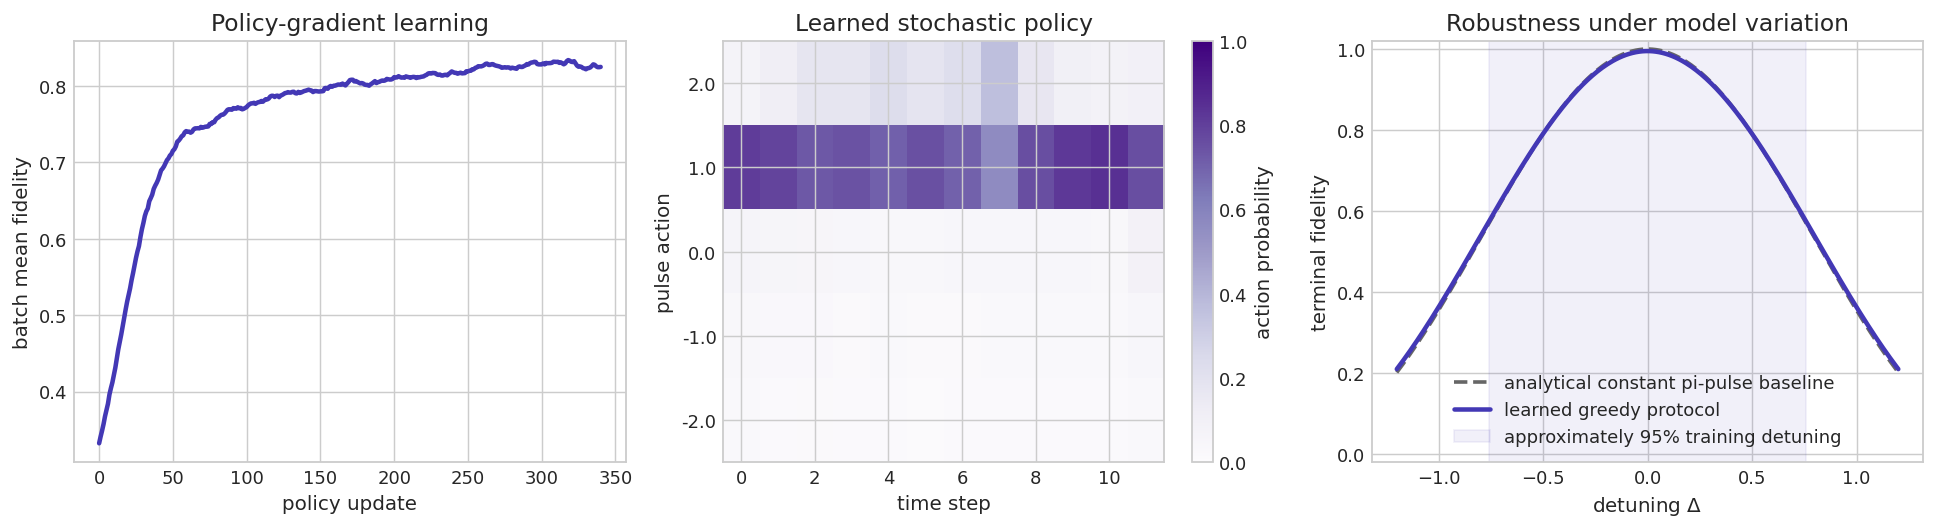

In [12]:
# The transparent physical baseline is a constant resonant pi pulse.
nominal_amplitude = np.pi / (pulse_horizon * pulse_dt)
nominal_pulses = np.full(pulse_horizon, nominal_amplitude)
detuning_grid = np.linspace(-1.2, 1.2, 301)

learned_fidelity = np.array([qubit_return(learned_actions, d)[1] for d in detuning_grid])
nominal_fidelity = np.array([
    qubit_fidelity_from_pulses(nominal_pulses, d) for d in detuning_grid
])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(moving_average(qubit_fidelities, 20), color=UIO_PURPLE, lw=2.5)
axes[0].set(xlabel="policy update", ylabel="batch mean fidelity",
            title="Policy-gradient learning")

image = axes[1].imshow(learned_probabilities.T, origin="lower", aspect="auto",
                       cmap="Purples", vmin=0, vmax=1)
axes[1].set(xlabel="time step", ylabel="pulse action",
            yticks=np.arange(len(pulse_values)), yticklabels=pulse_values,
            title="Learned stochastic policy")
fig.colorbar(image, ax=axes[1], label="action probability")

axes[2].plot(detuning_grid, nominal_fidelity, "--", color="0.4", lw=2,
             label="analytical constant pi-pulse baseline")
axes[2].plot(detuning_grid, learned_fidelity, color=UIO_PURPLE, lw=2.5,
             label="learned greedy protocol")
axes[2].axvspan(-0.76, 0.76, color=UIO_PURPLE, alpha=0.07,
                label="approximately 95% training detuning")
axes[2].set(xlabel=r"detuning $\Delta$", ylabel="terminal fidelity",
            ylim=(-0.02, 1.02), title="Robustness under model variation")
axes[2].legend()
plt.tight_layout()
plt.show()

### Interpretation and limitations

The learned parameters generalize across the sampled detuning distribution. This does not establish laboratory validity. A credible study would compare against GRAPE or another optimal-control baseline, test unseen noise models, include decoherence and hardware bandwidth, report the complete distribution of fidelity, and evaluate sensitivity to simulator mismatch.

The Dicke-state example discussed in Lecture 5 is much more demanding. A spinor Bose-Einstein condensate is controlled through a bounded quadratic Zeeman shift. The reported PPO policy uses observables and sensitivity-based rewards to learn a fast nonadiabatic protocol across a quantum phase transition. The point is not that a neural policy replaces physics; function approximation makes a reusable policy over continuous observations and controls possible.

## 8. Choosing an algorithm

| Problem property | Natural starting point | Reason |
|---|---|---|
| Discrete actions, reusable off-policy data | DQN or fitted Q-learning | one value per action and replay |
| Continuous bounded controls | actor-critic or PPO | direct action-distribution model |
| Sparse terminal reward | Monte Carlo policy gradient | complete episode outcome is available |
| Long horizon | TD critic | bootstrapped intermediate learning signal |
| Partial observations | recurrent policy or belief state | current observation is not sufficient |
| Accurate differentiable simulator | optimal control or model-based method | gradients and structure may be more efficient |

Function approximation solves a representation problem. It does not repair an insufficient observation, a misaligned reward, an unrealistic simulator, or a weak evaluation design.

## Problem set

1. For $\widehat v(s;\mathbf w)=\mathbf w^\top\boldsymbol\phi(s)$, derive the semi-gradient TD(0) update from the squared one-step TD error.
2. In the random-walk example, change the number and width of the radial basis functions. Explain the resulting bias-generalization trade-off.
3. Remove the target network from the DQN implementation. Repeat ten seeds and compare loss, return, and estimated $Q$-value scale.
4. Explain why replay makes DQN off-policy. Which policy generated an old transition, and which policy defines the current target?
5. Derive $\nabla_\theta\log\pi_\theta(a\mid s)$ for a softmax policy with logits $z_\theta(s,a)$.
6. Explain the two different clipping regimes in the PPO figure for positive and negative advantages.
7. Add amplitude and slew-rate constraints to the qubit environment. Should they be enforced by the action parametrization, by penalties, or by both?
8. Replace the open-loop qubit policy by a policy that observes noisy estimates of $\langle\sigma_z\rangle$. What additional state or memory is needed?

**Mini-project.** Compare the learned qubit protocol with a direct numerical optimization of the same pulse sequence. Use identical control bounds, noise samples, and evaluation data. Report fidelity distributions, computation time, and out-of-distribution performance rather than only the best achieved fidelity.

## Summary

The mathematical progression is

$$
V(s),Q(s,a)
\longrightarrow
\widehat v(s;\mathbf w),\widehat q(s,a;\mathbf w)
\longrightarrow
\pi_\theta(a\mid s).
$$

- Linear features make generalization and interference explicit.
- Monte Carlo and TD differ through their targets, not through the optimizer alone.
- DQN combines approximate Q-learning with replay and a delayed target network.
- Policy gradients optimize the policy directly; critics reduce gradient variance.
- PPO limits destructive probability-ratio changes.
- In physics, function approximation must be combined with constraints, physical baselines, uncertainty tests, and external validation.

**Further reading:** Lecture 5, *Function Approximation in Reinforcement Learning*; Sutton and Barto, Chapters 9-13; Bukov and Marquardt, [*Reinforcement Learning for Quantum Technology*](https://arxiv.org/abs/2601.18953), especially the discussion of quantum state preparation.